# Method Comparison Simulations

Compare the old user implementation, collaborator implementation, and merged implementation on noisy ring, S-curve, and Swiss roll simulations with velocity fields.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd()
if not (repo_root / "scripts").exists():
    repo_root = repo_root.parent.parent
sys.path.insert(0, str(repo_root))

from scripts.reference_implementations.jingyuan_velocity_manifold_fitter import VelocityManifoldFitter as JingyuanFitter
from scripts.reference_implementations.collaborator_velocity_manifold_fitting_demo import VMFParams, fit_velocity_mf
from scripts.velocity_manifold_fitter import VelocityManifoldFitter as MergedFitter

In [2]:
def normalize_rows(X, eps=1e-12):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + eps)


def make_ring(n=450, radius=1.0, sigma_embed=0.12, sigma_v=0.22, seed=7):
    rng = np.random.default_rng(seed)
    theta = np.sort(rng.uniform(0, 2 * np.pi, size=n))
    clean = radius * np.c_[np.cos(theta), np.sin(theta), np.zeros(n)]
    tangent = np.c_[-np.sin(theta), np.cos(theta), np.zeros(n)]
    embed_noise = rng.normal(scale=sigma_embed, size=clean.shape)
    X = clean + embed_noise
    W = tangent + rng.normal(scale=sigma_v, size=tangent.shape)
    return {"name": "ring", "X": X, "W": W, "truth": clean, "V_true": tangent, "color": theta, "view": (80, -90)}


def make_s_curve(n=450, sigma_embed=0.20, sigma_v=0.10, seed=11):
    rng = np.random.default_rng(seed)
    t = np.sort(3 * np.pi * (rng.uniform(size=n) - 0.5))
    y = 2.0 * rng.uniform(size=n)
    clean = np.empty((n, 3), dtype=float)
    clean[:, 0] = np.sin(t)
    clean[:, 1] = y
    clean[:, 2] = np.sign(t) * (np.cos(t) - 1.0)

    dt = np.c_[np.cos(t), np.zeros(n), -np.sign(t) * np.sin(t)]
    tangent = normalize_rows(dt)
    embed_noise = rng.normal(scale=sigma_embed, size=clean.shape)
    X = clean + embed_noise
    W = tangent + rng.normal(scale=sigma_v, size=tangent.shape)
    return {"name": "s_curve", "X": X, "W": W, "truth": clean, "V_true": tangent, "color": t, "view": (18, -70)}


def make_swiss_roll(n=600, sigma_embed=1.0, sigma_v=1.0, seed=13):
    rng = np.random.default_rng(seed)
    t = np.sort(rng.uniform(1.5 * np.pi, 4.5 * np.pi, size=n))
    h = rng.uniform(0.0, 8.0, size=n)
    clean = np.c_[t * np.cos(t), h, t * np.sin(t)]
    dt = np.c_[np.cos(t) - t * np.sin(t), np.zeros(n), np.sin(t) + t * np.cos(t)]
    tangent = normalize_rows(dt)
    embed_noise = rng.normal(scale=sigma_embed, size=clean.shape)
    X = clean + embed_noise
    W = tangent + rng.normal(scale=sigma_v, size=tangent.shape)
    return {"name": "swiss_roll", "X": X, "W": W, "truth": clean, "V_true": tangent, "color": t, "view": (20, -60)}


datasets = [make_ring(), make_s_curve(), make_swiss_roll()]

In [3]:
def run_methods(data):
    X, W = data["X"], data["W"]

    jingyuan_fit = JingyuanFitter(
        X,
        W,
        k=25,
        d=2,
        theta=0.25,
        gamma=8.0,
        beta=2.0,
        kappa=1.0,
        T=8,
        random_state=0,
        candidate_mult=4,
    )
    X_jingyuan = jingyuan_fit.fit(mode="unweighted")

    params = VMFParams(k=25, d=2, n_iter=8, theta=0.25, gamma=8.0, beta=2.0, kappa=1.0)
    collab_original = fit_velocity_mf(X, W, params, mode="original")

    merged_original = MergedFitter(X, W, random_state=0).fit(
        update_mode="original",
        return_dict=True,
    )
    merged_normal = MergedFitter(X, W, random_state=0).fit(
        update_mode="normal_only",
        return_dict=True,
    )

    return [
        ("Noisy input", X, W),
        ("Jingyuan", X_jingyuan, jingyuan_fit.v),
        ("Yiqing original", collab_original["Z"], collab_original["V"]),
        ("Merged original", merged_original["X"], merged_original["V"]),
        ("Merged normal-only", merged_normal["X"], merged_normal["V"]),
    ]


all_results = {data["name"]: run_methods(data) for data in datasets}

In [4]:
def velocity_cosine(Vhat, Vtrue):
    denom = np.linalg.norm(Vhat, axis=1) * np.linalg.norm(Vtrue, axis=1) + 1e-12
    return float(np.mean(np.sum(Vhat * Vtrue, axis=1) / denom))


def rmse(Z, truth):
    return float(np.sqrt(np.mean(np.sum((Z - truth) ** 2, axis=1))))


summary = []
for data in datasets:
    name = data["name"]
    truth = data["truth"]
    V_true = data["V_true"]
    for method, Z, V in all_results[name]:
        summary.append(
            {
                "dataset": name,
                "method": method,
                "rmse_to_clean": rmse(Z, truth),
                "velocity_cosine": velocity_cosine(V, V_true),
                "mean_displacement": float(np.mean(np.linalg.norm(Z - data["X"], axis=1))),
            }
        )

summary

[{'dataset': 'ring',
  'method': 'Noisy input',
  'rmse_to_clean': 0.20886153191671225,
  'velocity_cosine': 0.9538388091399401,
  'mean_displacement': 0.0},
 {'dataset': 'ring',
  'method': 'Jingyuan',
  'rmse_to_clean': 0.2660419074028514,
  'velocity_cosine': 0.8654177248318902,
  'mean_displacement': 0.20847738487614806},
 {'dataset': 'ring',
  'method': 'Yiqing original',
  'rmse_to_clean': 0.8442262705836406,
  'velocity_cosine': 0.8126374725769191,
  'mean_displacement': 0.8644363096037108},
 {'dataset': 'ring',
  'method': 'Merged original',
  'rmse_to_clean': 0.964797505344587,
  'velocity_cosine': 0.2410752571642009,
  'mean_displacement': 0.9748044943027652},
 {'dataset': 'ring',
  'method': 'Merged normal-only',
  'rmse_to_clean': 0.18365665301205136,
  'velocity_cosine': 0.8965445607445484,
  'mean_displacement': 0.1767346547031712},
 {'dataset': 's_curve',
  'method': 'Noisy input',
  'rmse_to_clean': 0.34827143694986645,
  'velocity_cosine': 0.9901287826563464,
  'mean_d

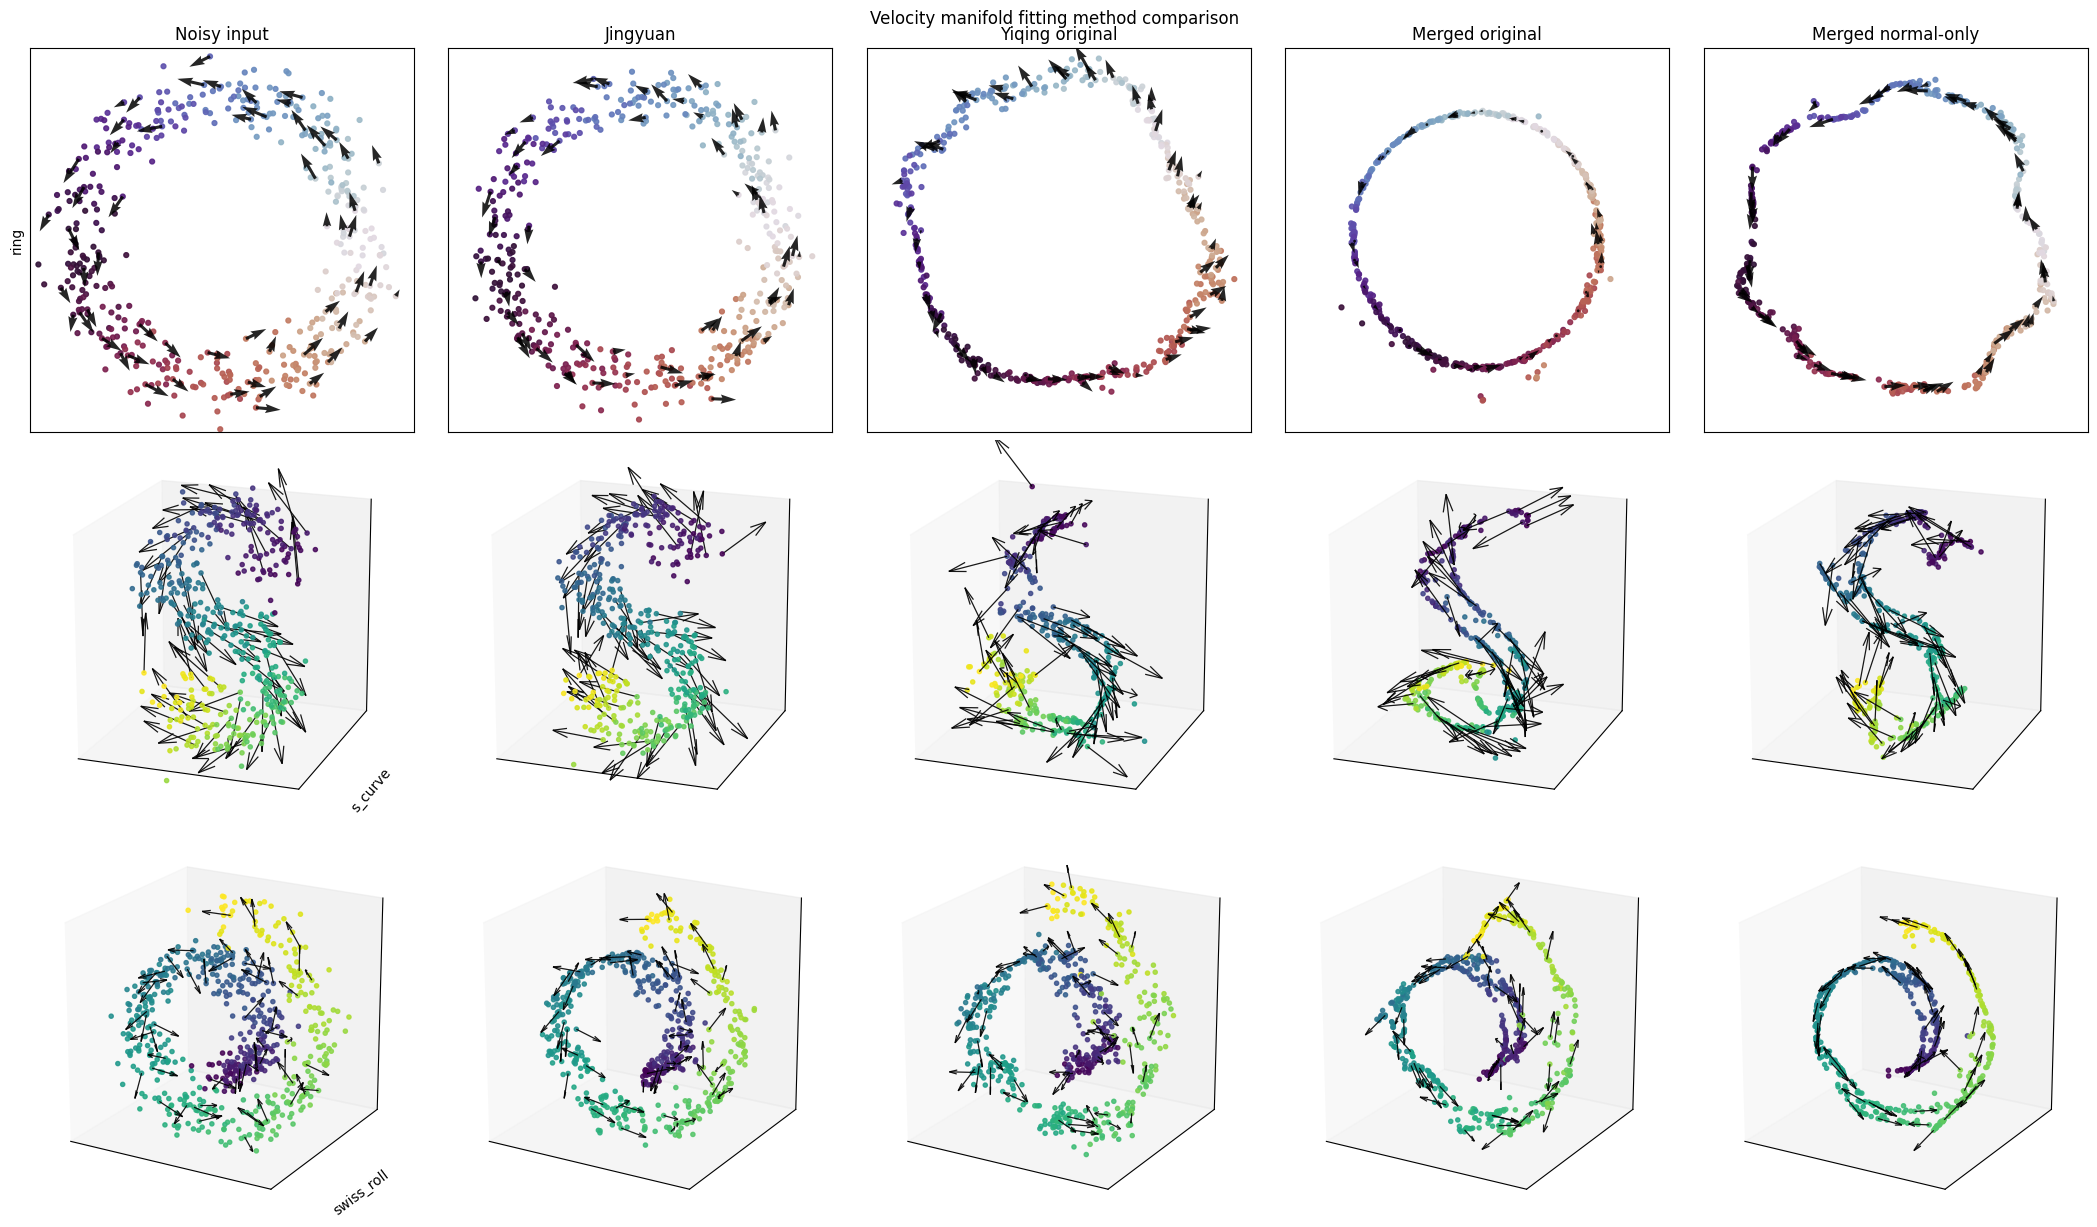

In [5]:
def set_equal_3d_limits(ax, X):
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    centers = (mins + maxs) / 2
    radius = np.max(maxs - mins) / 2
    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_zlim(centers[2] - radius, centers[2] + radius)
    try:
        ax.set_box_aspect((1, 1, 1))
    except Exception:
        pass


nrows = len(datasets)
ncols = len(next(iter(all_results.values())))
fig = plt.figure(figsize=(4.2 * ncols, 4.0 * nrows), constrained_layout=True)

for row, data in enumerate(datasets):
    results = all_results[data["name"]]
    color = data["color"]
    elev, azim = data["view"]
    step = max(1, data["X"].shape[0] // 55)

    for col, (title, Z, V) in enumerate(results):
        if data["name"] == "ring":
            ax = fig.add_subplot(nrows, ncols, row * ncols + col + 1)
            ax.scatter(Z[:, 0], Z[:, 1], c=color, cmap="twilight", s=12, alpha=0.9)
            ax.quiver(
                Z[::step, 0], Z[::step, 1],
                V[::step, 0], V[::step, 1],
                angles="xy",
                scale_units="xy",
                scale=7,
                width=0.008,
                color="black",
                alpha=0.85,
            )
            ax.set_aspect("equal")
            ax.set_xlim(data["truth"][:, 0].min() - 0.35, data["truth"][:, 0].max() + 0.35)
            ax.set_ylim(data["truth"][:, 1].min() - 0.35, data["truth"][:, 1].max() + 0.35)
            ax.set_xticks([])
            ax.set_yticks([])
        else:
            ax = fig.add_subplot(nrows, ncols, row * ncols + col + 1, projection="3d")
            ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=color, cmap="viridis", s=9, alpha=0.85)
            ax.quiver(
                Z[::step, 0], Z[::step, 1], Z[::step, 2],
                V[::step, 0], V[::step, 1], V[::step, 2],
                length=1.1 if data["name"] != "swiss_roll" else 3.1,
                normalize=True,
                color="black",
                linewidth=0.9,
                alpha=0.9,
            )
            ax.view_init(elev=elev, azim=azim)
            set_equal_3d_limits(ax, data["truth"])
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_zticks([])
        if row == 0:
            ax.set_title(title)
        if col == 0:
            ax.set_ylabel(data["name"])

fig.suptitle("Velocity manifold fitting method comparison", y=1.01)
plt.show()